# 03 — Benchmark Execution: kontrollált LLM-kísérlet

Ebben a notebookban lefuttatjuk ugyanazt a benchmarkot P0–P7 promptokon. A cél nem pusztán predictionök generálása, hanem **auditálható mérés**: minden requesthez elmentjük a raw választ, parse-olt labelt, token usage-et, latencyt, estimated costot és error státuszt.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

from IPython.display import Image, display

Project root: <PROJECT_ROOT>


## 0/A. Melyik LLM providert futtatjuk?

Ugyanaz a benchmark öt különböző backenddel használható:

`mock / ollama / groq / gemini / openai`

A prompt-engineering kísérletben **egy provider és egy model marad fix P0–P7 között**. Ez azért fontos, mert különben nem tudnánk eldönteni, hogy az F1-változást a prompt vagy maga a modell okozta.

Ingyenes valódi LLM-hez az Ollama a kvótamentes lokális út; Groq és Gemini pedig free-tier cloud opció.


In [2]:
import os

PROVIDER = os.getenv("LLM_PROVIDER", "mock")
print("Notebook provider:", PROVIDER)
print("Raw result folder:", PROJECT_ROOT / "07_outputs/results/raw" / PROVIDER)


Notebook provider: mock
Raw result folder: <PROJECT_ROOT>/07_outputs/results/raw/mock


## 1. Miért CLI-first a benchmark?

Az API-futtatás több száz vagy több ezer request lehet. Notebook esetén könnyebb véletlenül cellát újrafuttatni. A CLI runner ezért:

- checkpointol minden request után;
- kihagyja a már elkészült sample-eket;
- `--limit` opcióval olcsón tesztelhető;
- `--dry-run` esetén nem hív API-t;
- `--force` csak tudatos újrafuttatáskor szükséges.

A notebook elsősorban magyarázza és elemzi a folyamatot.

## 2. Konfiguráció betöltése

A modell és benchmark paraméterei konfigurációból jönnek. Ez azért fontos, mert az eredmény csak akkor reprodukálható, ha tudjuk, milyen modellel és milyen beállításokkal futott.

In [3]:
from prompt_benchmark.config import load_yaml

benchmark_config = load_yaml(PROJECT_ROOT / "configs/benchmark.yaml")
pricing_config = load_yaml(PROJECT_ROOT / "configs/pricing.yaml")
print("Benchmark config:", benchmark_config)
print("Pricing config:", pricing_config)


Benchmark config: {'model': '', 'temperature': None, 'max_output_tokens': 64, 'random_seed': 42, 'benchmark_samples_per_class': 50, 'development_samples_per_class': 50, 'few_shot_examples_per_class': 2, 'bootstrap_iterations': 1000}
Pricing config: {'mock': {'input_per_million_tokens': 0.0, 'output_per_million_tokens': 0.0, 'note': 'Offline prompt-sensitivity simulator. Token/latency values are estimated/simulated, not provider measurements.'}, 'ollama': {'input_per_million_tokens': 0.0, 'output_per_million_tokens': 0.0, 'note': 'Local inference; no per-token API charge. Electricity/hardware cost is not modeled.'}, 'groq': {'input_per_million_tokens': 0.075, 'output_per_million_tokens': 0.3, 'note': 'Reference list-price equivalent for openai/gpt-oss-20b. Actual charge can be $0 while you stay within Groq Free Plan quota.'}, 'gemini': {'input_per_million_tokens': 0.75, 'output_per_million_tokens': 3.75, 'note': 'Reference paid-tier equivalent for gemini-3.8-flash through 2026-12-31. Ge

## 3. Final holdout betöltése

A final holdout ugyanaz minden P0–P7 futásnál. Ha még nem készült el, futtasd a data preparation scriptet.

In [4]:
import pandas as pd

benchmark_path = PROJECT_ROOT / "01_data/processed/benchmark.csv"
if not benchmark_path.exists():
    raise FileNotFoundError("Run: python 05_scripts/02_prepare_data.py --source sample ... OR --source huggingface")

benchmark = pd.read_csv(benchmark_path)
print("Benchmark rows:", len(benchmark))
print(benchmark["true_label"].value_counts().sort_index())
benchmark.head()


Benchmark rows: 300
true_label
api             50
billing         50
cancellation    50
complaint       50
technical       50
upgrade         50
Name: count, dtype: int64


,sample_id,text,true_label,case_type,difficulty,secondary_label,scenario_id,scenario_notes
0,bench_0000,"Hi support, the application crashes whenever i...",technical,noisy_typo,medium,api,technical_noisy_typo_100,"Typos, casing and punctuation noise reduce lex..."
1,bench_0001,Could you help? My credit card payment for Bas...,upgrade,ambiguous_boundary,hard,billing,upgrade_ambiguous_boundary_058,Contains a strong billing cue before the actua...
2,bench_0002,"Hello, This service has been frustrating for w...",complaint,easy_clear,easy,technical,complaint_easy_clear_056,Single explicit intent with strong lexical cues.
3,bench_0003,"Hello. For context, last month we discussed on...",api,long_context,hard,billing,api_long_context_045,Long irrelevant context contains distractor in...
4,bench_0004,"Good morning, Where can I find the API documen...",technical,ambiguous_boundary,hard,api,technical_ambiguous_boundary_042,Contains a strong api cue before the actual te...


## 4. Dry-run: mit küldenénk az API-nak?

Fizetős futtatás előtt mindig érdemes ellenőrizni a rendered promptot. Így prompt-template vagy few-shot hiba nem több száz request után derül ki.

In [5]:
from prompt_benchmark.prompts import get_strategy

sample_ticket = benchmark.iloc[0]["text"]
for name in ["p0_zero_shot", "p3_few_shot", "p7_structured_output"]:
    payload = get_strategy(name).build(sample_ticket)
    print("=" * 90)
    print(name)
    print("instructions:", payload.instructions)
    print("output_mode:", payload.output_mode, "structured_output:", payload.structured_output)
    print(payload.input_text[:2500])


p0_zero_shot
instructions: None
output_mode: label structured_output: False
Classify this customer support message into one of: api, billing, cancellation, complaint, technical, upgrade.
Message: Hi support, the application crashes whenever i  open file upload. thanks. Reference: CS-00580.
Return only the category.
p3_few_shot
instructions: You are a precise SaaS customer-support routing classifier.
output_mode: label structured_output: False
Category definitions:
- api: API usage, authentication, endpoints, SDKs, integrations, API keys, or rate limits.
- billing: invoices, charges, payments, refunds, pricing, or payment failures.
- cancellation: explicit intent to cancel, terminate, stop, or not renew a subscription.
- complaint: general dissatisfaction or escalation without a more specific primary category.
- technical: bugs, crashes, errors, broken product behavior, login/application/system failures.
- upgrade: changing plan/tier, adding capacity/seats, upgrading or downgrading a su

## 5. API-költségvédelmi sorrend

Javasolt futási sorrend:

1. `--dry-run` → 0 API request;
2. `--limit 10` P0 → parser + API kapcsolat ellenőrzése;
3. `--limit 10` P7 → Structured Outputs ellenőrzése;
4. teljes P0–P7 benchmark.

Ez mérnöki szempontból jobb, mint rögtön 8 × 300 requestet elindítani.

In [6]:
print("python 05_scripts/04_run_benchmark.py --provider openai --strategy all --dry-run")
print("python 05_scripts/04_run_benchmark.py --provider openai --strategy p0_zero_shot --limit 10")
print("python 05_scripts/04_run_benchmark.py --provider openai --strategy p7_structured_output --limit 10")
print("python 05_scripts/04_run_benchmark.py --provider openai --strategy all")


python 05_scripts/04_run_benchmark.py --provider openai --strategy all --dry-run
python 05_scripts/04_run_benchmark.py --provider openai --strategy p0_zero_shot --limit 10
python 05_scripts/04_run_benchmark.py --provider openai --strategy p7_structured_output --limit 10
python 05_scripts/04_run_benchmark.py --provider openai --strategy all


## 6. Offline teljes smoke benchmark

A repository mock kliense nem LLM. Kulcsszavas logikával csak azt ellenőrzi, hogy a pipeline végig működik-e.

**Fontos:** mock F1-et tilos portfólióban LLM-eredményként kommunikálni.

In [7]:
print("One-command offline validation:")
print("python 05_scripts/09_run_smoke_test.py")


One-command offline validation:
python 05_scripts/09_run_smoke_test.py


## 7. Mi kerül elmentésre minden requesthez?

A row-level log a benchmark bizonyítéka. Nem csak aggregált F1-et tárolunk.

In [8]:
from prompt_benchmark.benchmark.runner import RESULT_COLUMNS
RESULT_COLUMNS


['sample_id',
 'text',
 'true_label',
 'case_type',
 'difficulty',
 'secondary_label',
 'scenario_id',
 'scenario_notes',
 'predicted_label',
 'correct',
 'raw_response',
 'valid_output',
 'valid_json',
 'input_tokens',
 'output_tokens',
 'total_tokens',
 'token_source',
 'latency_seconds',
 'latency_source',
 'estimated_cost_usd',
 'provider',
 'model',
 'prompt_strategy',
 'temperature',
 'top_p',
 'top_k',
 'reasoning_effort',
 'branch_count',
 'timestamp',
 'error']

### Miért kell a `raw_response`?

Ha csak a predicted label maradna meg, később nem tudnánk megvizsgálni, hogy a hiba classification-hiba volt-e vagy például formatting failure. A raw output segít reprodukálni és debugolni a parser döntését.

## 8. Meglévő raw benchmark eredmények betöltése

In [9]:
from pathlib import Path

raw_paths = sorted((PROJECT_ROOT / "07_outputs/results/raw" / PROVIDER).glob("p*.csv"))
[(p.name, len(pd.read_csv(p))) for p in raw_paths]


[('p0_zero_shot.csv', 300),
 ('p10_format_audience_tone.csv', 300),
 ('p11_delimited_data.csv', 300),
 ('p12_contrastive_few_shot.csv', 300),
 ('p13_reasoning_model.csv', 300),
 ('p14_tree_branch_vote.csv', 300),
 ('p15_grammar_constrained.csv', 300),
 ('p16_full_advanced_template.csv', 300),
 ('p1_definitions.csv', 300),
 ('p2_role.csv', 300),
 ('p3_few_shot.csv', 300),
 ('p4_constraints.csv', 300),
 ('p5_decision_policy.csv', 300),
 ('p6_json.csv', 300),
 ('p7_structured_output.csv', 300),
 ('p8_persona.csv', 300),
 ('p9_instruction_context.csv', 300)]

## 9. Egy stratégia raw outputjának ellenőrzése

Mielőtt aggregált metrikát számítunk, nézzük meg néhány request teljes sorát.

In [10]:
if raw_paths:
    raw_example = pd.read_csv(raw_paths[0])
    display_columns = [
        "sample_id", "true_label", "predicted_label", "correct",
        "valid_output", "input_tokens", "output_tokens",
        "latency_seconds", "estimated_cost_usd", "error"
    ]
    display(raw_example[display_columns].head(10))
else:
    print("No raw files yet. Run the benchmark first.")


,sample_id,true_label,predicted_label,correct,valid_output,input_tokens,output_tokens,latency_seconds,estimated_cost_usd,error
0,bench_0000,technical,NaN,False,False,61,8,0.2859,0.0,NaN
1,bench_0001,upgrade,NaN,False,False,108,8,0.2969,0.0,NaN
2,bench_0002,complaint,complaint,True,True,69,1,0.2580,0.0,NaN
3,bench_0003,api,technical,False,True,131,1,0.2876,0.0,NaN
4,bench_0004,technical,NaN,False,False,110,8,0.3043,0.0,NaN
5,bench_0005,technical,api,False,True,134,1,0.2909,0.0,NaN
6,bench_0006,complaint,complaint,True,True,72,1,0.2875,0.0,NaN
7,bench_0007,cancellation,cancellation,True,True,129,1,0.2808,0.0,NaN
8,bench_0008,api,api,True,True,68,1,0.2735,0.0,NaN
9,bench_0009,complaint,complaint,True,True,118,1,0.2769,0.0,NaN


## 10. Miért Macro F1 az elsődleges quality metric?

Accuracy = helyes predictionök aránya. Ez hasznos, de nem mutatja meg, hogy minden kategória jól működik-e.

Macro F1:

1. minden osztályra külön F1-et számít;
2. a hat F1-et azonos súllyal átlagolja.

Ezért egy gyenge `cancellation` teljesítményt nem tud elfedni egy nagyon erős `technical` kategória.

## 11. Miért mérünk latencyt és tokent is?

Prompt engineering productionban multi-objective optimalizáció:

- **Quality:** F1 / Accuracy;
- **Reliability:** valid output / JSON;
- **Efficiency:** token usage / cost;
- **Performance:** P95 latency.

Egy prompt nem tekinthető automatikusan jobbnak csak azért, mert 0.5 százalékponttal magasabb az F1-e.

## 12. Aggregate report generálása

A report script automatikusan előállítja a leaderboardot, per-class riportokat és több mint húsz ábrát.

In [11]:
print("python 05_scripts/07_generate_report.py")


python 05_scripts/07_generate_report.py


## 13. Leaderboard megtekintése

In [12]:
summary_path = PROJECT_ROOT / "07_outputs/results/benchmark_summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    display(summary.sort_values("macro_f1", ascending=False))
else:
    print("Run 05_scripts/07_generate_report.py first.")


,requests,correct_count,incorrect_count,invalid_output_count,api_error_count,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,invalid_output_rate,output_contract_valid_rate,invalid_json_rate,json_grammar_valid_rate,error_rate,mean_input_tokens,mean_output_tokens,mean_total_tokens,total_input_tokens,total_output_tokens,total_tokens,tokens_per_correct_prediction,mean_latency_seconds,median_latency_seconds,p50_latency_seconds,p95_latency_seconds,p99_latency_seconds,total_latency_seconds,sequential_throughput_rps,mean_cost_usd,cost_per_1000_requests_usd,benchmark_cost_usd,cost_per_correct_prediction_usd,mean_branch_count,provider,model,strategy,temperature,top_p,top_k,token_source,latency_source,macro_f1_ci_low,macro_f1_ci_high,absolute_f1_improvement_vs_p0,relative_f1_improvement_vs_p0_pct,token_overhead_vs_p0_pct,latency_overhead_vs_p0_pct,invalid_output_reduction_vs_p0_pp
0,300.0,284.0,16.0,0.0,0.0,0.946667,0.947522,0.946667,0.946599,0.946599,0.000000,1.000000,NaN,NaN,0.0,1388.460000,3.046667,1391.506667,416538.0,914.0,417452.0,1469.901408,1.520574,1.52190,1.52190,1.590605,1.612003,456.1722,0.657646,0.0,0.0,0.0,0.0,3.0,mock,mock-prompt-sensitive-simulator-v2,p14_tree_branch_vote,0.0,1.0,40,estimated_mock,simulated_mock,0.920880,0.969377,0.293317,44.898891,1283.711757,400.158795,10.000000
1,300.0,275.0,25.0,0.0,0.0,0.916667,0.922594,0.916667,0.917515,0.917515,0.000000,1.000000,0.00,1.00,0.0,1595.210000,12.000000,1607.210000,478563.0,3600.0,482163.0,1753.320000,1.049916,1.04975,1.04975,1.082600,1.088400,314.9747,0.952457,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p16_full_advanced_template,0.0,1.0,40,estimated_mock,simulated_mock,0.883127,0.946595,0.264232,40.446882,1498.206769,240.418842,10.000000
2,300.0,268.0,32.0,0.0,0.0,0.893333,0.898330,0.893333,0.894515,0.894515,0.000000,1.000000,NaN,NaN,0.0,464.903333,25.000000,489.903333,139471.0,7500.0,146971.0,548.399254,0.788863,0.78815,0.78815,0.820710,0.825701,236.6589,1.267647,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p13_reasoning_model,0.0,1.0,40,estimated_mock,simulated_mock,0.859018,0.928096,0.241233,36.926207,387.159004,158.068675,10.000000
3,300.0,251.0,49.0,4.0,0.0,0.836667,0.853710,0.836667,0.844015,0.844015,0.013333,0.986667,NaN,NaN,0.0,1332.736667,1.093333,1333.830000,399821.0,328.0,400149.0,1594.219124,0.851766,0.85240,0.85240,0.887315,0.891907,255.5299,1.174031,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p5_decision_policy,0.0,1.0,40,estimated_mock,simulated_mock,0.803720,0.882243,0.190733,29.196038,1226.358182,179.012326,8.666667
4,300.0,250.0,50.0,0.0,0.0,0.833333,0.838115,0.833333,0.834862,0.834862,0.000000,1.000000,0.00,1.00,0.0,313.886667,12.000000,325.886667,94166.0,3600.0,97766.0,391.064000,0.462568,0.46375,0.46375,0.493810,0.500503,138.7705,2.161843,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p15_grammar_constrained,0.0,1.0,40,estimated_mock,simulated_mock,0.791219,0.873012,0.181580,27.794951,224.061122,55.276398,10.000000
5,300.0,247.0,53.0,0.0,0.0,0.823333,0.844088,0.823333,0.826353,0.826353,0.000000,1.000000,0.00,1.00,0.0,1313.580000,12.000000,1325.580000,394074.0,3600.0,397674.0,1610.016194,0.870355,0.87165,0.87165,0.902725,0.909225,261.1064,1.148957,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p7_structured_output,0.0,1.0,40,estimated_mock,simulated_mock,0.779354,0.867150,0.173070,26.492395,1218.154397,183.857933,10.000000
6,300.0,242.0,58.0,9.0,0.0,0.806667,0.843613,0.806667,0.821044,0.821044,0.030000,0.970000,0.03,0.97,0.0,1359.653333,11.910000,1371.563333,407896.0,3573.0,411469.0,1700.285124,0.863370,0.86215,0.86215,0.894540,0.900005,259.0109,1.158252,0.0,0.0,0.0,0.0,1.0,mock,mock-prompt-sensitive-simulator-v2,p6_json,0.0,1.0,40,estimated_mock,simulated_mock,0.777314,0.861138,0.167761,25.679727,1263.880142,181.284196,7.000000
7,300.0,244.0,56.0,2.0,0.0,0.813333,0.833533,0.813333,0.818540,0.818540,0.006667,0.993333,NaN,NaN,0.0,1316.140000,1.046667,1317.186667,39484

## 14. Bootstrap confidence interval

A Macro F1 pontbecslés. Véges benchmarknál kis különbségek lehetnek mintavételi zajból.

Ezért 1000 bootstrap resample alapján 95%-os CI-t számítunk. Ez **nem arra való, hogy automatikusan szignifikanciát deklaráljunk**, hanem arra, hogy a bizonytalanság látható legyen.

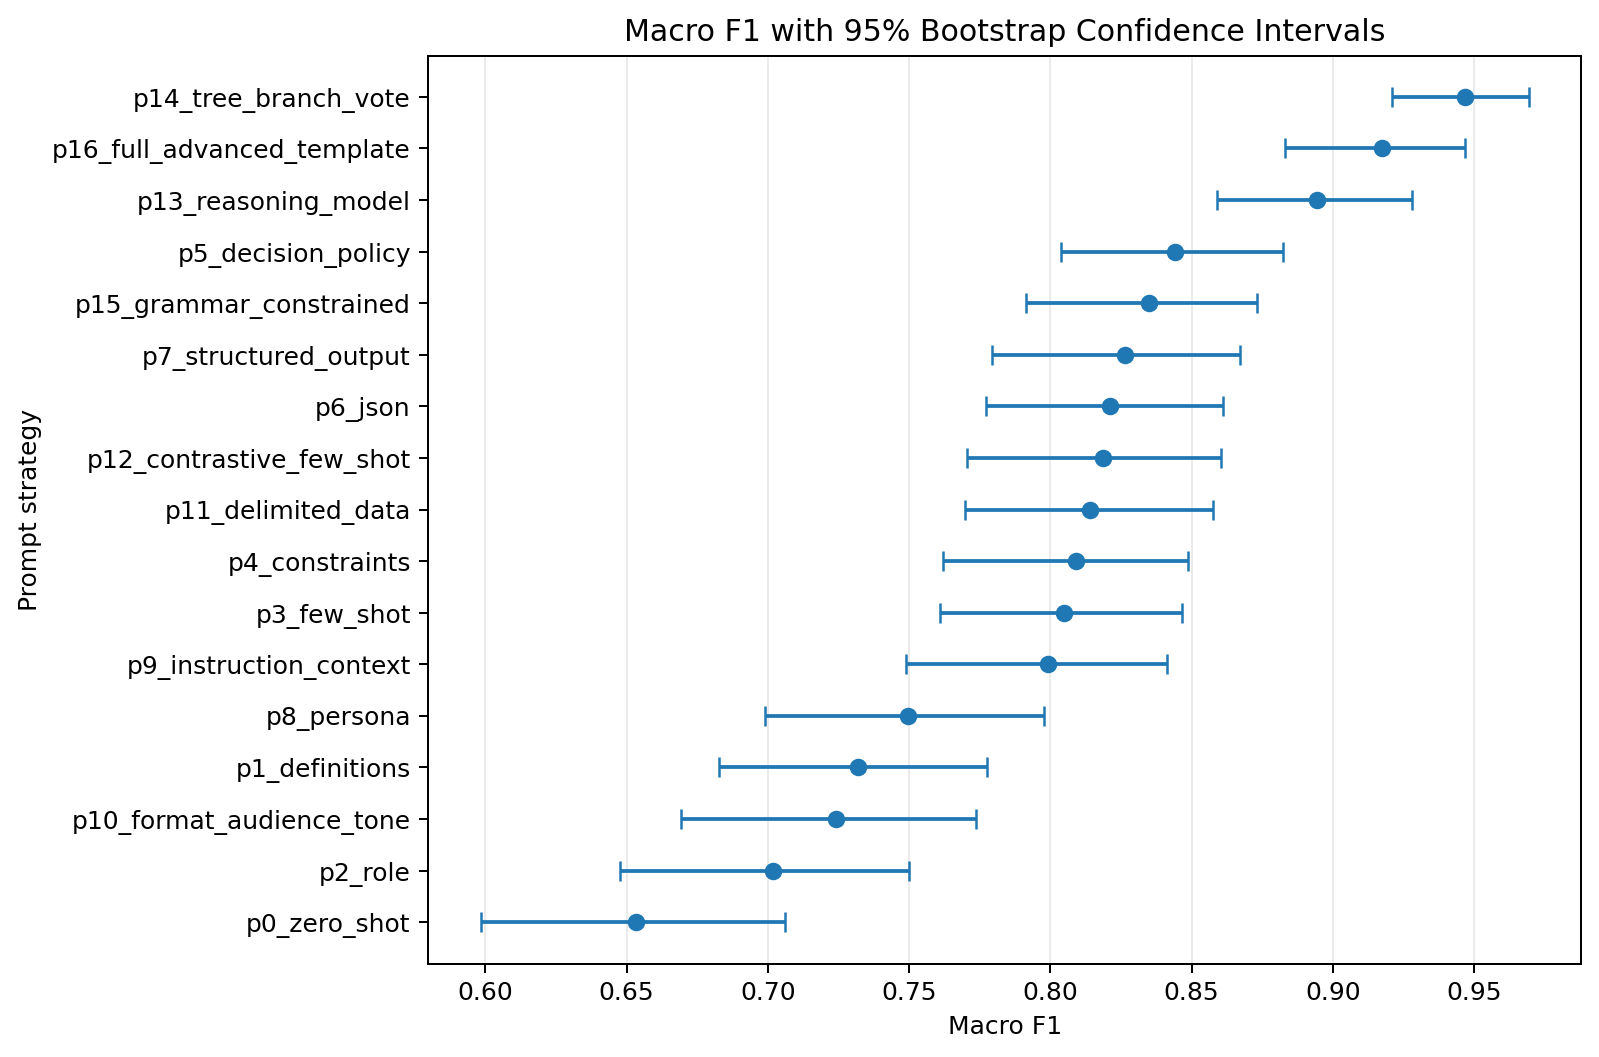

In [13]:
ci_figure = PROJECT_ROOT / "07_outputs/reports/figures" / PROVIDER / "11_macro_f1_bootstrap_ci.png"
if ci_figure.exists():
    display(Image(filename=str(ci_figure)))


## 15. Token és latency eloszlások

Az átlag önmagában kevés. A boxplot megmutatja, hogy egy stratégia mennyire stabil vagy mennyire vannak hosszú/kiugró requestek.

In [14]:
for filename in ["14_latency_distribution_boxplot.png", "15_token_distribution_boxplot.png"]:
    path = PROJECT_ROOT / "07_outputs/reports/figures" / filename
    if path.exists():
        display(Image(filename=str(path)))


## 16. Mit tekintünk sikeres benchmarkfutásnak?

A futás akkor auditálható, ha:

- minden P0–P7 fájl ugyanannyi holdout mintát tartalmaz;
- ugyanaz a model string szerepel bennük;
- nincs nem várt API error;
- parsing validitás mérve van;
- token és latency mezők kitöltöttek;
- pricing konfiguráció rögzített;
- report reprodukálható ugyanabból a raw CSV-ből.

A következő notebookban nem új promptot írunk, hanem **hibákat elemzünk**.